# Loading and data processing

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
import scipy
import scipy.stats as stats
import scikit_posthocs as sp

from IPython.display import display

from termcolor import colored, cprint

from pathlib import Path

plt.rcParams['figure.figsize'] = [25, 10]
# sn.set_theme(style="darkgrid", font_scale=2)
sn.set_theme(style="ticks")

In [4]:
# EXPERIMENTS_DIR = ["denser_with_power_measure", "energize_power_10",
#                "energize_power_10_skip_connections", "energize_power_10_seed"]

# EXPERIMENTS = ("DENSER", "ENERGIZE", "ENERGIZE (w/ skip)")
# EXPERIMENTS_WITH_SEED = EXPERIMENTS + ("ENERGIZE (w/ seed)",)

EXPERIMENTS_DIR = ["denser_with_power_measure", "energize_power_10",
               "energize_power_10_freeze",]

EXPERIMENTS = ("DENSER", "ENERGIZE", "ENERGIZE (freeze)")
EXPERIMENTS_WITH_SEED = EXPERIMENTS

# DATASET = "fashionmnist"
DATASET = "cifar10"
# DATASET = "cifar100"


for i in range(1, len(EXPERIMENTS_DIR)):
    if DATASET != "fashionmnist":
        EXPERIMENTS_DIR[i] = f"{EXPERIMENTS_DIR[i]}_{DATASET}"

KEYS = ("fitness", "n_trainable_parameters", "accuracy_0", "accuracy_1",
        "power_train", "power_test_0_mean", "power_test_1_mean", "early_stop")

# KEYS = ("n_trainable_parameters",
#         "n_layers_0", "n_layers_1", "accuracy_0", "accuracy_1",
#         "power_train", "power_test_0_mean", "power_test_1_mean",\
#                 "energy_train", "energy_test_0_mean", "energy_test_1_mean")

KEYS_ENERGIZE_TO_DENSER = {
    'n_layers_0': 'n_layers',
    'n_layers_1': 'n_layers',
    'accuracy_0': 'accuracy',
    'accuracy_1': 'accuracy',
    'power_test_0_mean': 'power_test_mean',
    'power_test_1_mean': 'power_test_mean',
    'energy_test_0_mean': 'energy_test_mean',
    'energy_test_1_mean': 'energy_test_mean'
}

In [5]:
experiments_data = {}

for experiment_dir, experiment in zip(EXPERIMENTS_DIR, EXPERIMENTS_WITH_SEED):
    experiments_data[experiment] = {}
    experiments_data[experiment]['data'] = pd.read_csv(
        f"../experiments/{DATASET}/{experiment_dir}/data.csv")
    experiments_data[experiment]['shapiro'] = {}

In [6]:
for experiment in EXPERIMENTS_WITH_SEED:
    max_gen = experiments_data[experiment]['data']['gen'].max()
    print(f"Experiment: {experiment}, Max gen: {max_gen}")

Experiment: DENSER, Max gen: 149
Experiment: ENERGIZE, Max gen: 149
Experiment: ENERGIZE (freeze), Max gen: 149


In [11]:
CUTOFF_GEN = 150

# cut off at 150 gens
for experiment_dir, experiment in zip(EXPERIMENTS_DIR, EXPERIMENTS_WITH_SEED):
    experiments_data[experiment]['data'] = experiments_data[experiment]['data'][experiments_data[experiment]['data']['gen'] < CUTOFF_GEN]
    experiments_data[experiment]['data']['early_stop'] = experiments_data[experiment]['data']['phenotype'].str.extract(r'early_stop:(\d+)').astype(int)
    if experiment != 'DENSER':
        experiments_data[experiment]['data']['power_test_diff'] = experiments_data[experiment]['data']['power_test_1_mean'] - experiments_data[experiment]['data']['power_test_0_mean']
        experiments_data[experiment]['data']['partition_point'] = experiments_data[experiment]['data']['phenotype'].str.extract(r'partition_point:(\d+)').astype(int)
        # Extract the first element from the string representation of the list in 'n_layers'
        experiments_data[experiment]['data']['partition_point'] = experiments_data[experiment]['data']['partition_point'] / experiments_data[experiment]['data']['n_layers'].apply(lambda x: int(eval(x)[0]))

In [12]:
for experiment in EXPERIMENTS_WITH_SEED:
    max_gen = experiments_data[experiment]['data']['gen'].max()
    print(f"Experiment: {experiment}, Max gen: {max_gen}")

Experiment: DENSER, Max gen: 149
Experiment: ENERGIZE, Max gen: 149
Experiment: ENERGIZE (freeze), Max gen: 149


In [13]:
a = experiments_data['ENERGIZE']['data']['accuracy_0'] - experiments_data['ENERGIZE']['data']['accuracy_1']
print(f"accuracy\n{a.min():10.2e}")
print(f"{a.max():10.2e}")
print(f"{a.mean():10.5f}\n")

a = experiments_data['ENERGIZE']['data']['power_test_0_mean'] - experiments_data['ENERGIZE']['data']['power_test_1_mean']
print(f"power\n{a.min():10.2e}")
print(f"{a.max():10.2e}")
print(f"{a.mean():10.5f}")

accuracy
 -9.00e-02
  1.32e-01
   0.00638

power
 -3.50e+01
  4.43e+01
   6.86875


# Statistic tests

#### Stats config


In [14]:
alpha = 0.05

Everything assumes the data does not follow a normal dist

Experiment: DENSER


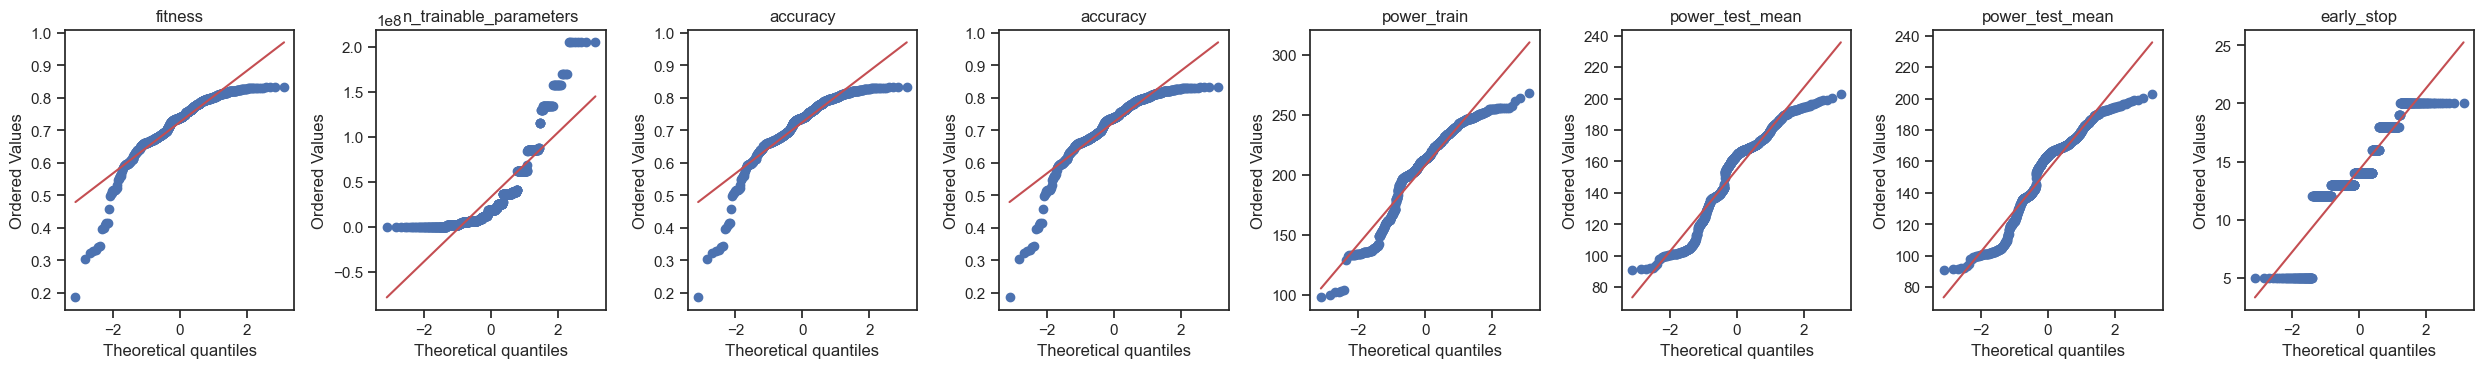

..Follows normal dist (Shapiro-Wilk test, alpha=0.05)
....fitness                  False | 0.87 | 8.46e-25
....n_trainable_parameters   False | 0.75 | 2.76e-32
....accuracy                 False | 0.87 | 8.46e-25
....accuracy                 False | 0.87 | 8.46e-25
....power_train              False | 0.93 | 1.63e-18
....power_test_mean          False | 0.93 | 1.06e-17
....power_test_mean          False | 0.93 | 1.06e-17
....early_stop               False | 0.87 | 3.19e-24



,fitness,n_trainable_parameters,accuracy,accuracy,power_train,power_test_mean,power_test_mean,early_stop
fitness,1.000000,-0.139084,1.000000,1.000000,0.208559,0.360469,0.360469,0.202029
n_trainable_parameters,-0.139084,1.000000,-0.139084,-0.139084,0.524891,0.609361,0.609361,-0.071558
accuracy,1.000000,-0.139084,1.000000,1.000000,0.208559,0.360469,0.360469,0.202029
accuracy,1.000000,-0.139084,1.000000,1.000000,0.208559,0.360469,0.360469,0.202029
power_train,0.208559,0.524891,0.208559,0.208559,1.000000,0.863574,0.863574,-0.042385
power_test_mean,0.360469,0.609361,0.360469,0.360469,0.863574,1.000000,1.000000,-0.064286
power_test_mean,0.360469,0.609361,0.360469,0.360469,0.863574,1.000000,1.000000,-0.064286
early_stop,0.202029,-0.071558,0.202029,0.202029,-0.042385,-0.064286,-0.064286,1.000000


,fitness,n_trainable_parameters,accuracy,accuracy,power_train,power_test_mean,power_test_mean,early_stop
fitness,1.000000e+00,1.328056e-04,0.000000e+00,0.000000e+00,8.135556e-09,1.976654e-24,1.976654e-24,2.388369e-08
n_trainable_parameters,1.328056e-04,1.000000e+00,1.328056e-04,1.328056e-04,2.484518e-54,1.956225e-77,1.956225e-77,5.011875e-02
accuracy,0.000000e+00,1.328056e-04,1.000000e+00,0.000000e+00,8.135556e-09,1.976654e-24,1.976654e-24,2.388369e-08
accuracy,0.000000e+00,1.328056e-04,0.000000e+00,1.000000e+00,8.135556e-09,1.976654e-24,1.976654e-24,2.388369e-08
power_train,8.135556e-09,2.484518e-54,8.135556e-09,8.135556e-09,1.000000e+00,1.229096e-224,1.229096e-224,2.463176e-01
power_test_mean,1.976654e-24,1.956225e-77,1.976654e-24,1.976654e-24,1.229096e-224,1.000000e+00,0.000000e+00,7.850543e-02
power_test_mean,1.976654e-24,1.956225e-77,1.976654e-24,1.976654e-24,1.229096e-224,0.000000e+00,1.000000e+00,7.850543e-02
early_stop,2.388369e-08,5.011875e-02,2.388369e-08,2.388369e-08,2.463176e-01,7.850543e-02,7.850543e-02,1.000000e+00


Experiment: ENERGIZE


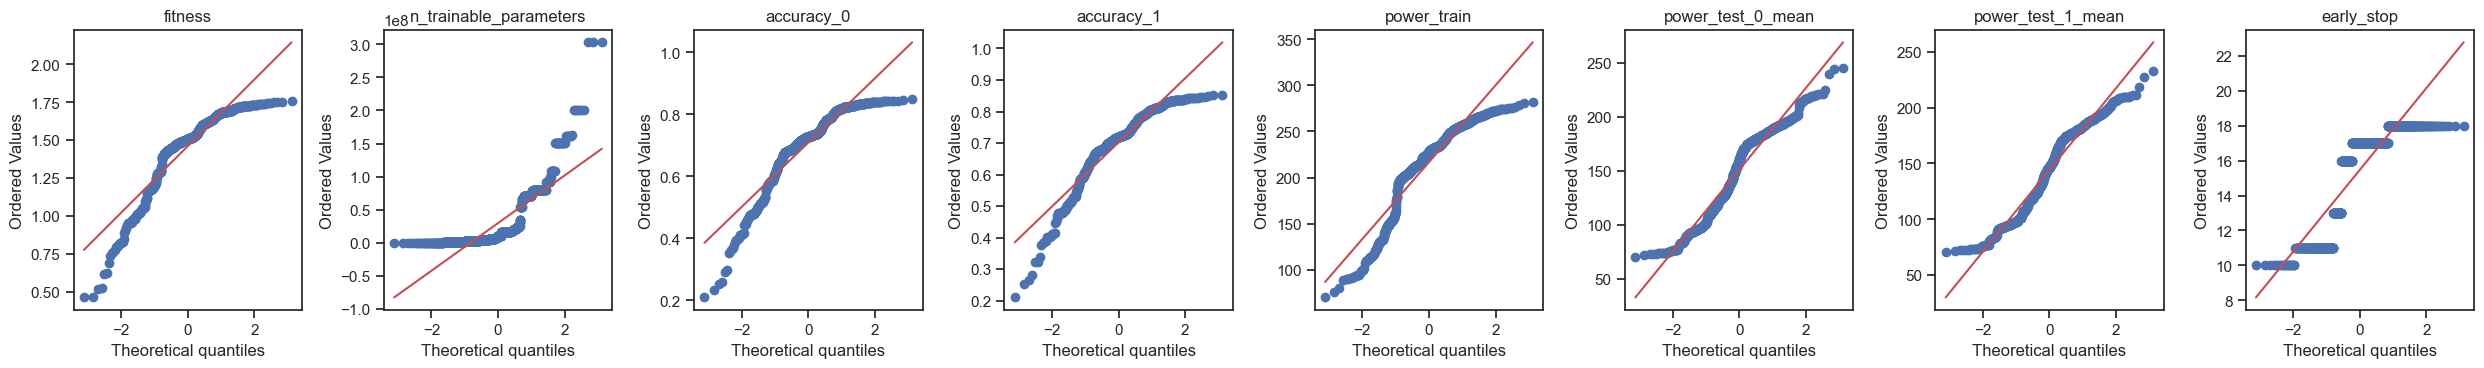

..Follows normal dist (Shapiro-Wilk test, alpha=0.05)
....fitness                  False | 0.87 | 1.10e-24
....n_trainable_parameters   False | 0.68 | 1.75e-35
....accuracy_0               False | 0.88 | 2.99e-23
....accuracy_1               False | 0.90 | 2.11e-21
....power_train              False | 0.89 | 4.20e-23
....power_test_0_mean        False | 0.95 | 1.01e-15
....power_test_1_mean        False | 0.95 | 1.24e-14
....early_stop               False | 0.76 | 8.01e-32



,fitness,n_trainable_parameters,accuracy_0,accuracy_1,power_train,power_test_0_mean,power_test_1_mean,early_stop
fitness,1.000000,-0.148017,0.981840,0.993639,0.681314,0.699393,0.767230,0.229172
n_trainable_parameters,-0.148017,1.000000,-0.083015,-0.134091,0.148619,0.246493,0.147920,-0.101441
accuracy_0,0.981840,-0.083015,1.000000,0.969854,0.716039,0.756977,0.803238,0.256552
accuracy_1,0.993639,-0.134091,0.969854,1.000000,0.696023,0.721890,0.792179,0.219527
power_train,0.681314,0.148619,0.716039,0.696023,1.000000,0.835215,0.826758,0.232091
power_test_0_mean,0.699393,0.246493,0.756977,0.721890,0.835215,1.000000,0.961418,0.255059
power_test_1_mean,0.767230,0.147920,0.803238,0.792179,0.826758,0.961418,1.000000,0.238501
early_stop,0.229172,-0.101441,0.256552,0.219527,0.232091,0.255059,0.238501,1.000000


,fitness,n_trainable_parameters,accuracy_0,accuracy_1,power_train,power_test_0_mean,power_test_1_mean,early_stop
fitness,1.000000e+00,4.715809e-05,0.000000e+00,0.000000e+00,1.911453e-103,3.318353e-111,1.985055e-146,2.147936e-10
n_trainable_parameters,4.715809e-05,1.000000e+00,2.299129e-02,2.307183e-04,4.388292e-05,7.641168e-12,4.770551e-05,5.425638e-03
accuracy_0,0.000000e+00,2.299129e-02,1.000000e+00,0.000000e+00,6.938123e-119,2.289274e-140,1.809212e-170,9.749695e-13
accuracy_1,0.000000e+00,2.307183e-04,0.000000e+00,1.000000e+00,1.026471e-109,1.020638e-121,1.400588e-162,1.230378e-09
power_train,1.911453e-103,4.388292e-05,6.938123e-119,1.026471e-109,1.000000e+00,1.945901e-196,4.700428e-189,1.246814e-10
power_test_0_mean,3.318353e-111,7.641168e-12,2.289274e-140,1.020638e-121,1.945901e-196,1.000000e+00,0.000000e+00,1.331161e-12
power_test_1_mean,1.985055e-146,4.770551e-05,1.809212e-170,1.400588e-162,4.700428e-189,0.000000e+00,1.000000e+00,3.679530e-11
early_stop,2.147936e-10,5.425638e-03,9.749695e-13,1.230378e-09,1.246814e-10,1.331161e-12,3.679530e-11,1.000000e+00


Experiment: ENERGIZE (freeze)


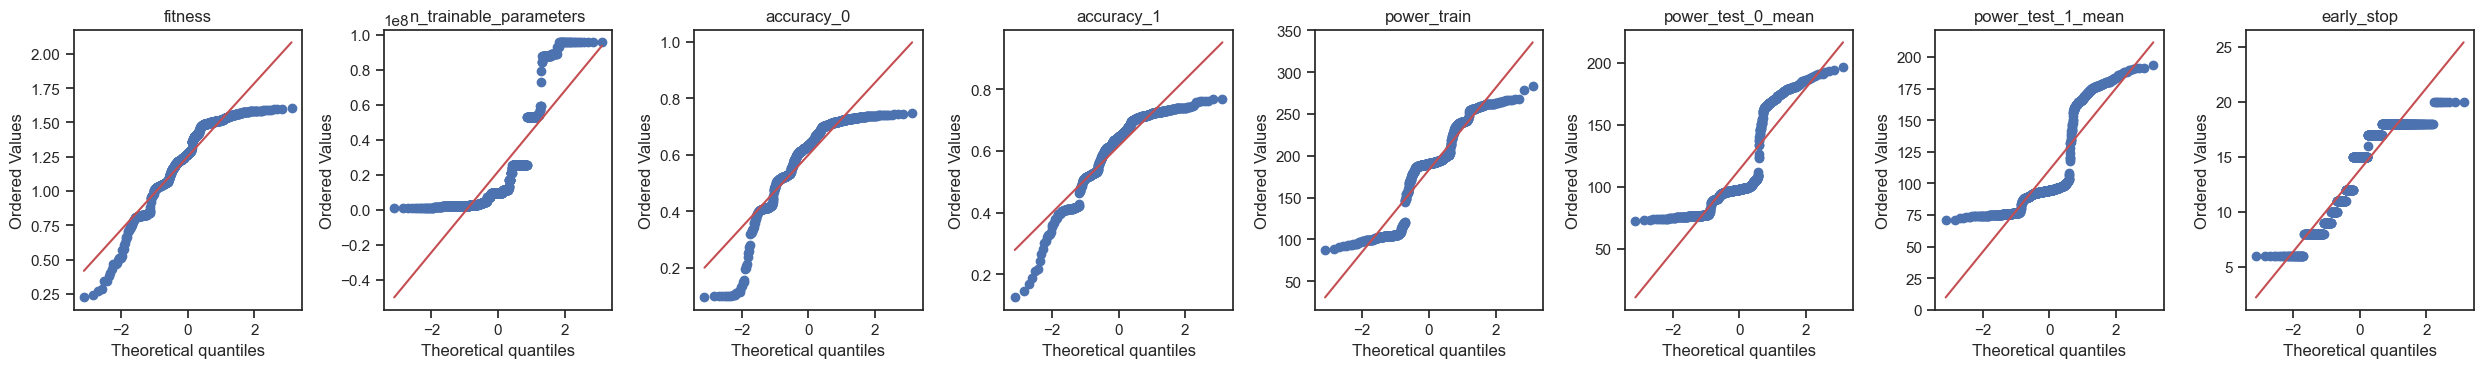

..Follows normal dist (Shapiro-Wilk test, alpha=0.05)
....fitness                  False | 0.91 | 9.58e-21
....n_trainable_parameters   False | 0.71 | 7.69e-34
....accuracy_0               False | 0.84 | 8.80e-27
....accuracy_1               False | 0.89 | 6.42e-23
....power_train              False | 0.91 | 4.56e-21
....power_test_0_mean        False | 0.79 | 9.95e-30
....power_test_1_mean        False | 0.77 | 4.17e-31
....early_stop               False | 0.89 | 4.62e-23



,fitness,n_trainable_parameters,accuracy_0,accuracy_1,power_train,power_test_0_mean,power_test_1_mean,early_stop
fitness,1.000000,-0.148953,0.982942,0.972754,0.580895,0.430801,0.387073,0.020538
n_trainable_parameters,-0.148953,1.000000,-0.034406,-0.109432,0.391562,0.349097,0.436369,-0.038461
accuracy_0,0.982942,-0.034406,1.000000,0.962621,0.611436,0.461097,0.430740,0.060213
accuracy_1,0.972754,-0.109432,0.962621,1.000000,0.629844,0.524672,0.485214,0.032512
power_train,0.580895,0.391562,0.611436,0.629844,1.000000,0.882778,0.863130,0.067976
power_test_0_mean,0.430801,0.349097,0.461097,0.524672,0.882778,1.000000,0.945837,0.091560
power_test_1_mean,0.387073,0.436369,0.430740,0.485214,0.863130,0.945837,1.000000,0.043200
early_stop,0.020538,-0.038461,0.060213,0.032512,0.067976,0.091560,0.043200,1.000000


,fitness,n_trainable_parameters,accuracy_0,accuracy_1,power_train,power_test_0_mean,power_test_1_mean,early_stop
fitness,1.000000e+00,4.216133e-05,0.000000e+00,0.000000e+00,6.887173e-69,3.044839e-35,3.234498e-28,0.574409
n_trainable_parameters,4.216133e-05,1.000000e+00,3.467241e-01,2.691390e-03,6.851394e-29,6.443196e-23,3.251384e-36,0.292836
accuracy_0,0.000000e+00,3.467241e-01,1.000000e+00,0.000000e+00,4.308796e-78,9.416673e-41,3.119303e-35,0.099403
accuracy_1,0.000000e+00,2.691390e-03,0.000000e+00,1.000000e+00,3.830495e-84,2.799370e-54,1.494801e-45,0.373934
power_train,6.887173e-69,6.851394e-29,4.308796e-78,3.830495e-84,1.000000e+00,1.269099e-247,3.793513e-224,0.062794
power_test_0_mean,3.044839e-35,6.443196e-23,9.416673e-41,2.799370e-54,1.269099e-247,1.000000e+00,0.000000e+00,0.012122
power_test_1_mean,3.234498e-28,3.251384e-36,3.119303e-35,1.494801e-45,3.793513e-224,0.000000e+00,1.000000e+00,0.237339
early_stop,5.744089e-01,2.928360e-01,9.940277e-02,3.739337e-01,6.279435e-02,1.212189e-02,2.373392e-01,1.000000


In [15]:
for experiment in EXPERIMENTS_WITH_SEED:
    print(f"Experiment: {experiment}")
    fig, axes = plt.subplots(1, len(KEYS), figsize=(25, 4))
    flattened_axes = np.ndarray.flatten(axes)

    normal_str = f"..Follows normal dist (Shapiro-Wilk test, alpha={alpha})\n"
    correlation_str = "..Correlation matrix\n"
    for i, k in enumerate(KEYS):
        if experiment == 'DENSER' and k in KEYS_ENERGIZE_TO_DENSER:
            k = KEYS_ENERGIZE_TO_DENSER[k]
        ax = flattened_axes[i]
        k_data = experiments_data[experiment]['data'][k]
        stats.probplot(list(k_data), dist="norm", plot=ax)
        ax.set_title(k)

        # shapiro-wilk test
        stat, p = stats.shapiro(k_data)
        normal = p > alpha
        experiments_data[experiment]['shapiro'][k] = {'stat': stat, 'p': p, 'normal': normal}
        normal_str += f"....{k:25}{colored(normal, 'green' if normal else 'red')} | {stat:.2f} | {p:.2e}\n"

    plt.tight_layout()
    plt.show()

    print(normal_str)

    # correlation coefficients
    keys = list(KEYS)
    if experiment == 'DENSER':
        keys = [KEYS_ENERGIZE_TO_DENSER[k] if k in KEYS_ENERGIZE_TO_DENSER else k for k in keys]

    corr_matrix_spearman_stat = experiments_data[experiment]['data'][keys].corr(method='spearman')
    corr_matrix_spearman_p = experiments_data[experiment]['data'][keys].corr(method=lambda i, j: stats.spearmanr(i, j)[1])

    display(corr_matrix_spearman_stat)
    display(corr_matrix_spearman_p)

# Charts

fitness


<Figure size 7500x3000 with 0 Axes>

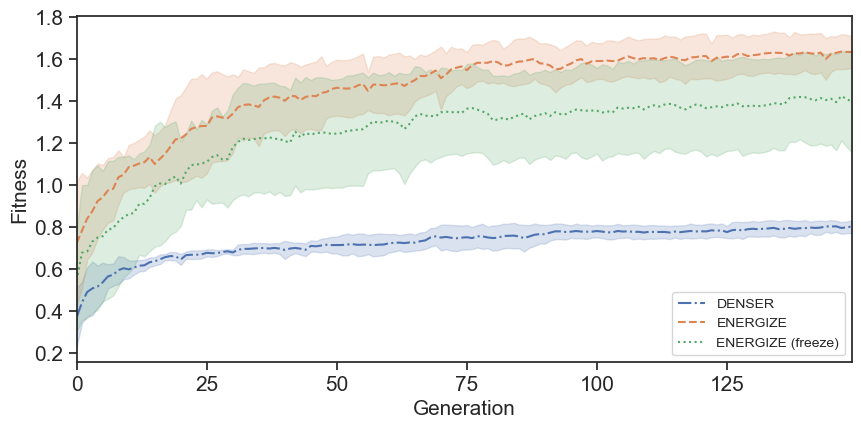

n_trainable_parameters


<Figure size 7500x3000 with 0 Axes>

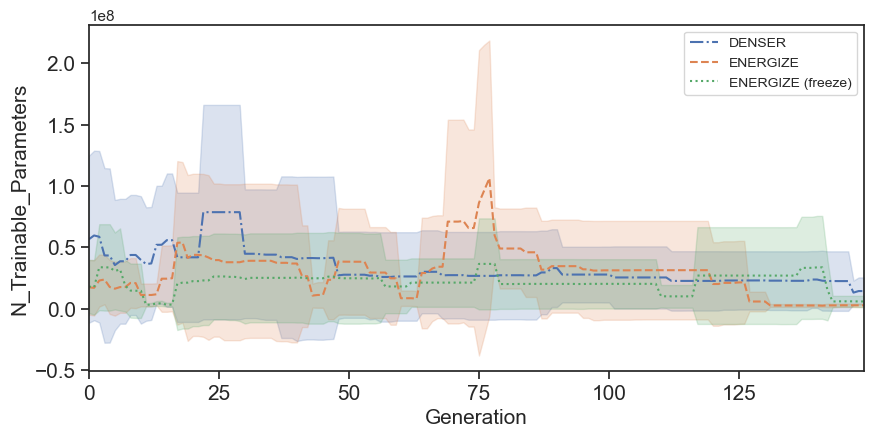

accuracy_0


<Figure size 7500x3000 with 0 Axes>

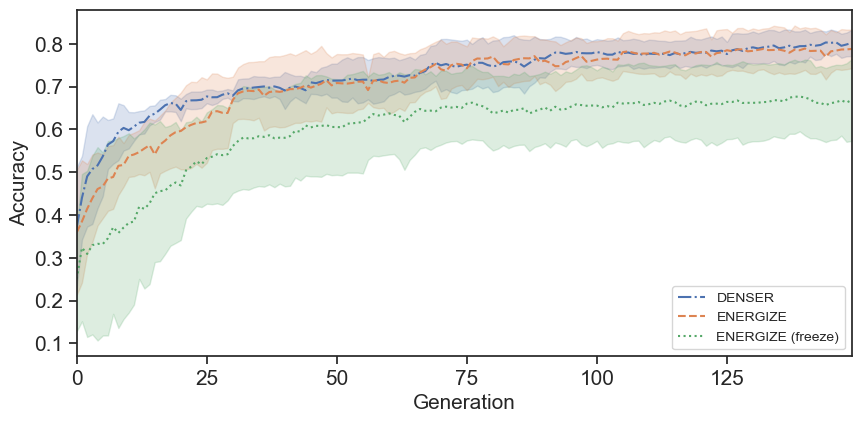

accuracy_1


<Figure size 7500x3000 with 0 Axes>

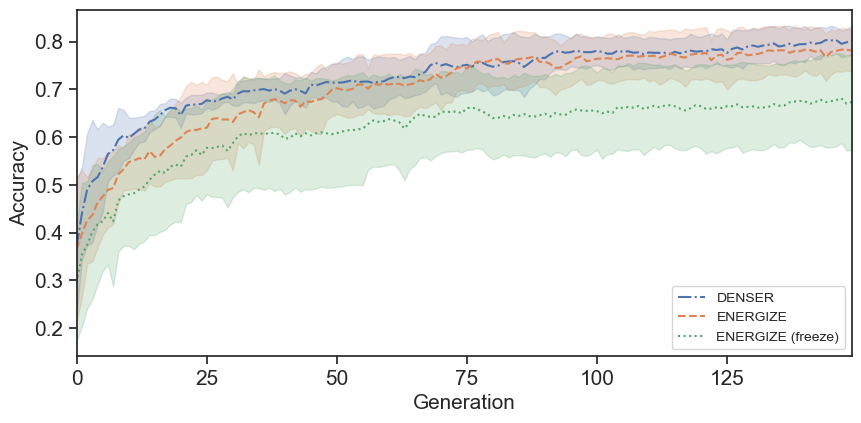

power_train


<Figure size 7500x3000 with 0 Axes>

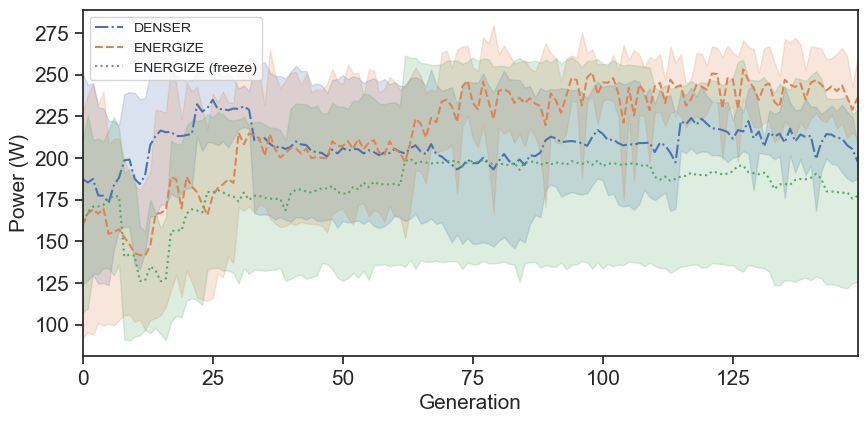

power_test_0_mean


<Figure size 7500x3000 with 0 Axes>

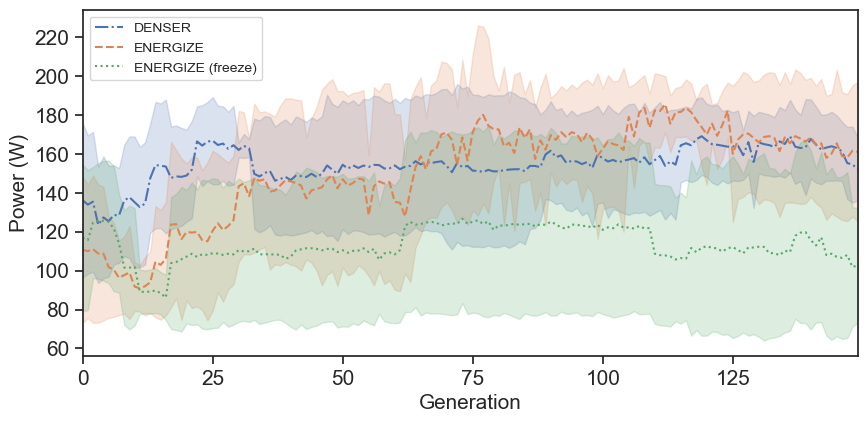

power_test_1_mean


<Figure size 7500x3000 with 0 Axes>

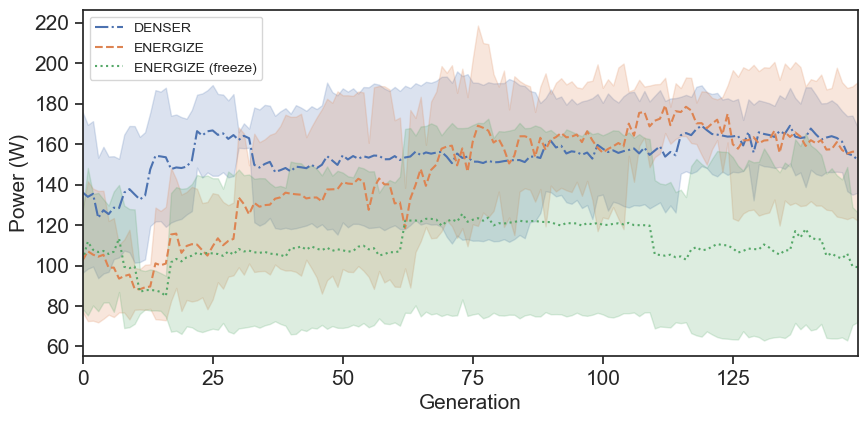

early_stop


<Figure size 7500x3000 with 0 Axes>

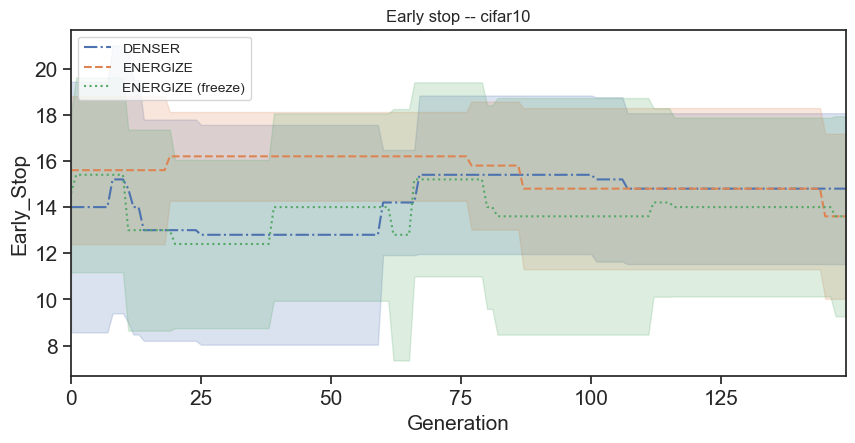

partition_point


<Figure size 7500x3000 with 0 Axes>

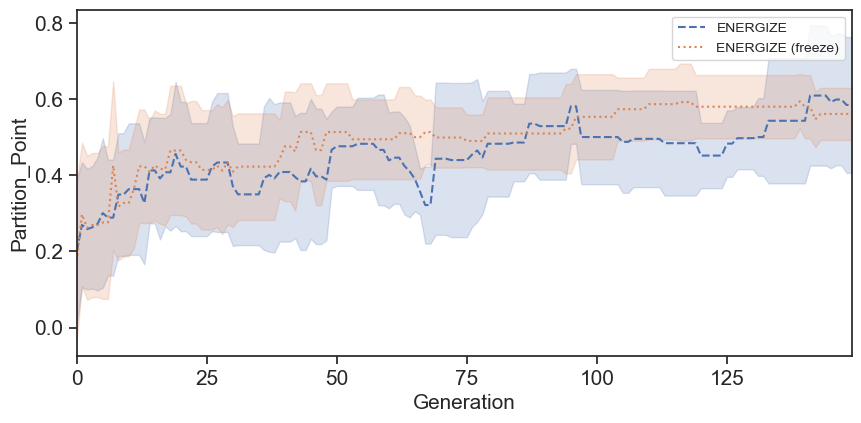

In [17]:
line_styles = {
    'DENSER': '-.',
    'ENERGIZE': '--',
    'ENERGIZE (w/ skip)': ':',
    'ENERGIZE (freeze)': ':'
}

for i, k in enumerate(KEYS + ("partition_point",)):
    plt.figure(dpi=300)
    print(k)
    fig, ax = plt.subplots(figsize=(10, 4.5))
    for experiment in EXPERIMENTS:
        if k == "partition_point" and experiment == 'DENSER':
            continue
        _k = k
        if experiment == 'DENSER' and k in KEYS_ENERGIZE_TO_DENSER:
            _k = KEYS_ENERGIZE_TO_DENSER[k]
        sn.lineplot(experiments_data[experiment]['data'], x='gen', y=_k, label=experiment, ax=ax, linestyle=line_styles[experiment], errorbar="sd")
    loc = "upper right"
    if k.startswith('accuracy'):
        loc = "lower right"
    elif k.startswith('power'):
        loc = "upper left"
    elif  k == "early_stop":
        loc = "upper left"
        plt.title(f"Early stop -- {DATASET}")
    elif k == "fitness":
        loc = "lower right"
    ax.legend(loc=loc, prop={'size': 10})
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    ax.set_xlabel('Generation', fontsize=15)
    if k.startswith('accuracy'):
        ylabel = 'Accuracy'
        ylim = (0.75, 0.95)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1f}'))  # Round y ticks to 1 decimal place

    elif k.startswith('power'):
        ylabel = 'Power (W)'
        ylim = (75, 185)
    else:
        ylabel = k.title()
        ylim = None

    ylim = None
    ax.set_ylabel(ylabel, fontsize=15)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.set_xlim(0, CUTOFF_GEN-1)

    ax.xaxis.set_major_locator(plt.MaxNLocator(6))

    if k in ('accuracy_0', 'power_test_0_mean'):
        plt.savefig(f"figures/{DATASET}_{k}.pdf", bbox_inches='tight')
    plt.show()

# Model partitions

<Figure size 7500x3000 with 0 Axes>

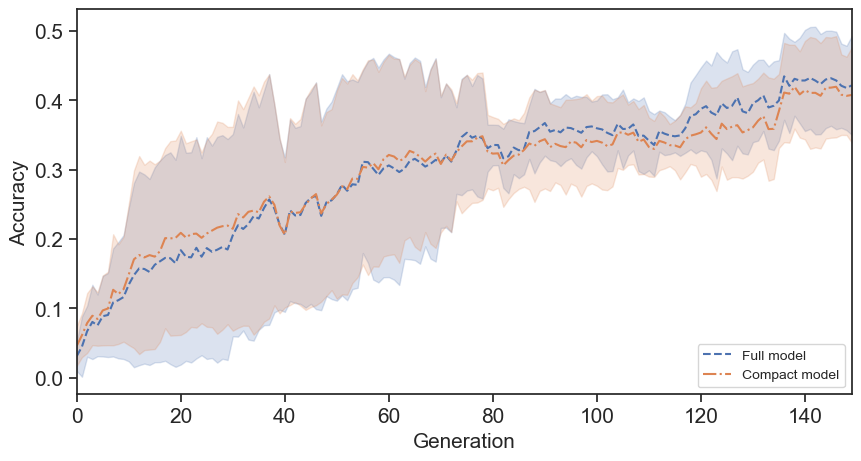

In [13]:
# accuracy
plt.figure(dpi=300)
fig, ax = plt.subplots(figsize=(10, 5))
sn.lineplot(experiments_data['ENERGIZE']['data'], x='gen', y='accuracy_0', label='Full model', ax=ax, errorbar="sd", linestyle='--')
sn.lineplot(experiments_data['ENERGIZE']['data'], x='gen', y='accuracy_1', label='Compact model', ax=ax, errorbar="sd", linestyle='-.')
loc = "lower right"
ax.legend(loc=loc, prop={'size': 10})
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
ax.set_xlabel('Generation', fontsize=15)
ylabel = 'Accuracy'
ax.set_ylabel(ylabel, fontsize=15)
ax.set_xlim(0, CUTOFF_GEN-1)
plt.savefig(f"figures/{DATASET}_energize_partition_accuracy.pdf", bbox_inches='tight')
plt.show()

<Figure size 7500x3000 with 0 Axes>

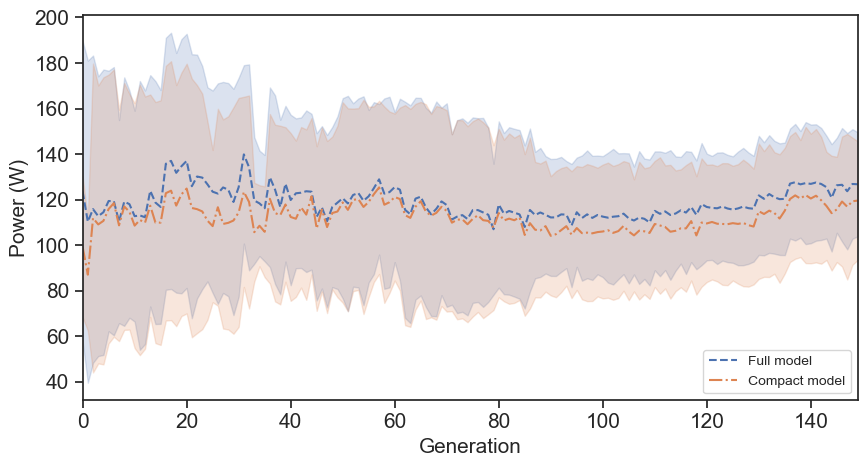

In [14]:
# power
plt.figure(dpi=300)
fig, ax = plt.subplots(figsize=(10, 5))
sn.lineplot(experiments_data['ENERGIZE']['data'], x='gen', y='power_test_0_mean', label='Full model', ax=ax, errorbar="sd", linestyle='--')
sn.lineplot(experiments_data['ENERGIZE']['data'], x='gen', y='power_test_1_mean', label='Compact model', ax=ax, errorbar="sd", linestyle='-.')
loc = "lower right"
ax.legend(loc=loc, prop={'size': 10})
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
ax.set_xlabel('Generation', fontsize=15)
ylabel = 'Power (W)'
ax.set_ylabel(ylabel, fontsize=15)
ax.set_xlim(0, CUTOFF_GEN-1)
plt.savefig(f"figures/{DATASET}_energize_partition_power.pdf", bbox_inches='tight')
plt.show()

# Seed model

<Figure size 7500x3000 with 0 Axes>

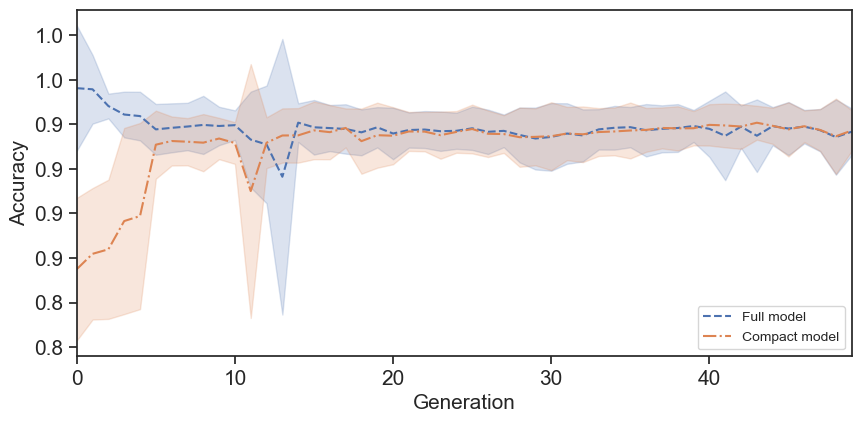

In [67]:
# seed - accuracy
plt.figure(dpi=300)
fig, ax = plt.subplots(figsize=(10, 4.5))
sn.lineplot(experiments_data['ENERGIZE (w/ seed)']['data'], x='gen', y='accuracy_0', label='Full model', ax=ax, errorbar="sd", linestyle='--')
sn.lineplot(experiments_data['ENERGIZE (w/ seed)']['data'], x='gen', y='accuracy_1', label='Compact model', ax=ax, errorbar="sd", linestyle='-.')
loc = "lower right"
ax.legend(loc=loc, prop={'size': 10})
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
ax.set_xlabel('Generation', fontsize=15)
ylabel = 'Accuracy'
ax.set_ylabel(ylabel, fontsize=15)
ax.set_xlim(0, 50-1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1f}'))  # Round y ticks to 1 decimal place

plt.savefig(f"figures/{DATASET}_energize_seed_accuracy.pdf", bbox_inches='tight')
plt.show()

<Figure size 7500x3000 with 0 Axes>

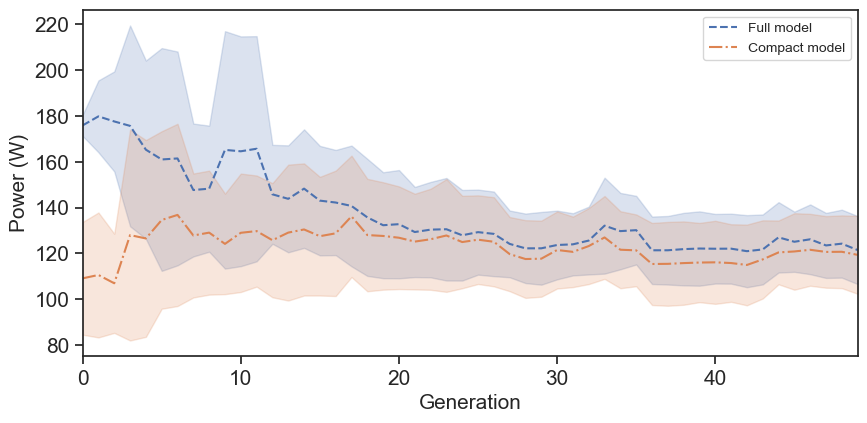

In [68]:
# seed - power
plt.figure(dpi=300)
fig, ax = plt.subplots(figsize=(10, 4.5))
sn.lineplot(experiments_data['ENERGIZE (w/ seed)']['data'], x='gen', y='power_test_0_mean', label='Full model', ax=ax, errorbar="sd", linestyle='--')
sn.lineplot(experiments_data['ENERGIZE (w/ seed)']['data'], x='gen', y='power_test_1_mean', label='Compact model', ax=ax, errorbar="sd", linestyle='-.')
loc = "upper right"
ax.legend(loc=loc, prop={'size': 10})
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
ax.set_xlabel('Generation', fontsize=15)
ylabel = 'Power (W)'
ax.set_ylabel(ylabel, fontsize=15)
ax.set_xlim(0, 50-1)
plt.savefig(f"figures/{DATASET}_energize_seed_power.pdf", bbox_inches='tight')
plt.show()

power_test_0_mean
power_test_1_mean


<Figure size 7500x3000 with 0 Axes>

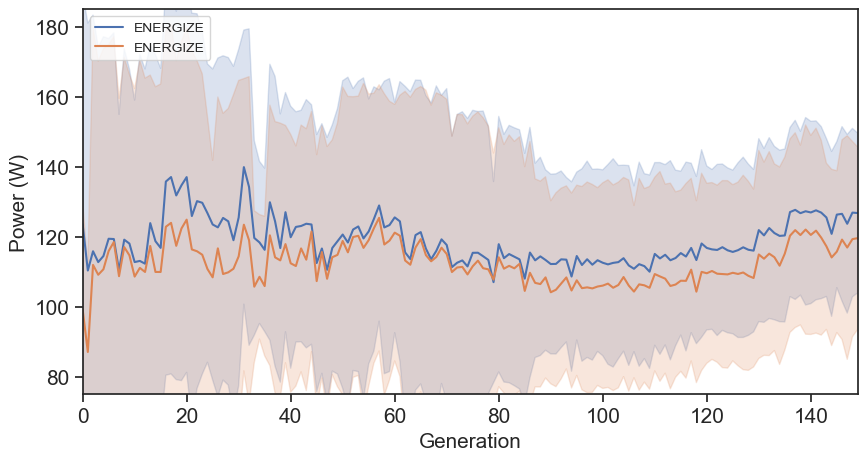

In [17]:
plt.figure(dpi=300)
fig, ax = plt.subplots(figsize=(10, 5))
# for i, k in enumerate(('accuracy_0', 'accuracy_1')):
for i, k in enumerate(('power_test_0_mean', 'power_test_1_mean')):
    print(k)
    for experiment in EXPERIMENTS[1:2]:
        _k = k
        if experiment == 'DENSER' and k in KEYS_ENERGIZE_TO_DENSER:
            _k = KEYS_ENERGIZE_TO_DENSER[k]
        sn.lineplot(experiments_data[experiment]['data'], x='gen', y=_k, label=experiment, ax=ax, errorbar="sd")
    loc = "upper right"
    if k.startswith('accuracy'):
        loc = "lower right"
    elif k.startswith('power'):
        loc = "upper left"
    ax.legend(loc=loc, prop={'size': 10})
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    ax.set_xlabel('Generation', fontsize=15)
    if k.startswith('accuracy'):
        ylabel = 'Accuracy'
        ylim = (0.75, 0.95)
    elif k.startswith('power'):
        ylabel = 'Power (W)'
        ylim = (75, 185)
    else:
        ylabel = k.title()
        ylim = None

    ax.set_ylabel(ylabel, fontsize=15)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.set_xlim(0, CUTOFF_GEN-1)

    # if k in ('accuracy_0', 'power_test_0_mean'):
    #     plt.savefig(f"figures/{k}.svg", bbox_inches='tight')
plt.show()

# Tests

Comparison (assumes normal dist is not followed)
1. Kruskal-Wallis
2. if H0 is rejected -> Mann-Whitney with Bonferroni correction

In [18]:
# group by generation and calculate mean
for experiment in EXPERIMENTS_WITH_SEED:
    keys = list(KEYS)
    if experiment == 'DENSER':
        keys = [KEYS_ENERGIZE_TO_DENSER[k] if k in KEYS_ENERGIZE_TO_DENSER else k for k in keys]
    experiments_data[experiment]['data'] = experiments_data[experiment]['data'][['gen', *keys]].groupby('gen').mean()
    if experiment == 'DENSER':
        experiments_data['DENSER']['data'] = experiments_data['DENSER']['data'].iloc[:, ~experiments_data['DENSER']['data'].columns.duplicated()]

Key: fitness
..Kruskal-Wallis test (alpha=0.05)
....stat=327.056 and p-value=9.566e-72
....reject H0 -> median is not equal across all groups
..Mann-Whitney U test (alpha=0.05, Bonferroni correction)


,DENSER,ENERGIZE,ENERGIZE (freeze)
DENSER,1.000000e+00,3.136999e-49,8.600931e-45
ENERGIZE,3.136999e-49,1.000000e+00,5.591349e-23
ENERGIZE (freeze),8.600931e-45,5.591349e-23,1.000000e+00


<Figure size 7500x3000 with 0 Axes>

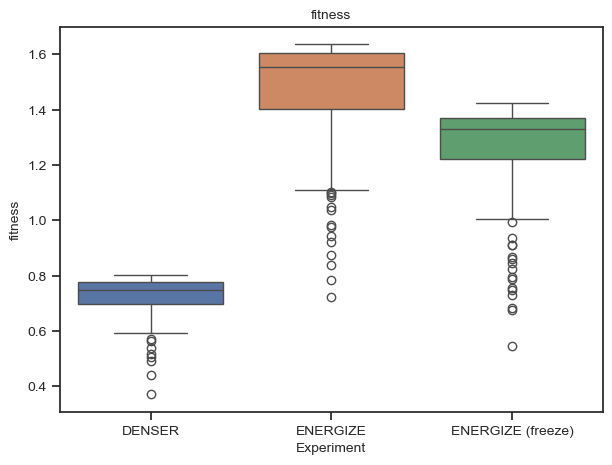

Key: n_trainable_parameters
..Kruskal-Wallis test (alpha=0.05)
....stat=71.292 and p-value=3.304e-16
....reject H0 -> median is not equal across all groups
..Mann-Whitney U test (alpha=0.05, Bonferroni correction)


,DENSER,ENERGIZE,ENERGIZE (freeze)
DENSER,1.000000e+00,0.964920,7.210705e-20
ENERGIZE,9.649200e-01,1.000000,2.705626e-06
ENERGIZE (freeze),7.210705e-20,0.000003,1.000000e+00


<Figure size 7500x3000 with 0 Axes>

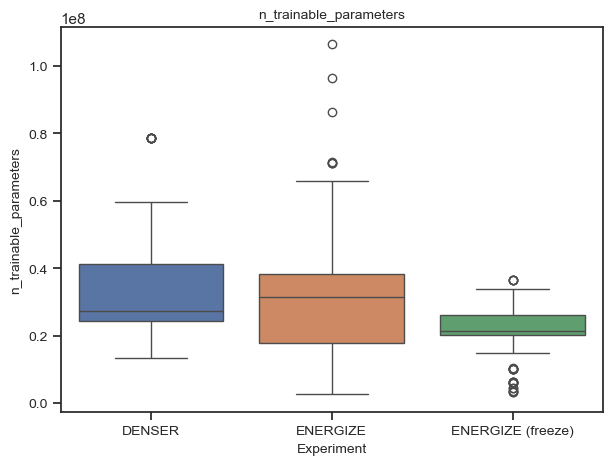

Key: accuracy_0
..Kruskal-Wallis test (alpha=0.05)
....stat=172.348 and p-value=3.759e-38
....reject H0 -> median is not equal across all groups
..Mann-Whitney U test (alpha=0.05, Bonferroni correction)


,DENSER,ENERGIZE,ENERGIZE (freeze)
DENSER,1.000000e+00,5.553854e-01,1.286931e-33
ENERGIZE,5.553854e-01,1.000000e+00,6.886033e-25
ENERGIZE (freeze),1.286931e-33,6.886033e-25,1.000000e+00


<Figure size 7500x3000 with 0 Axes>

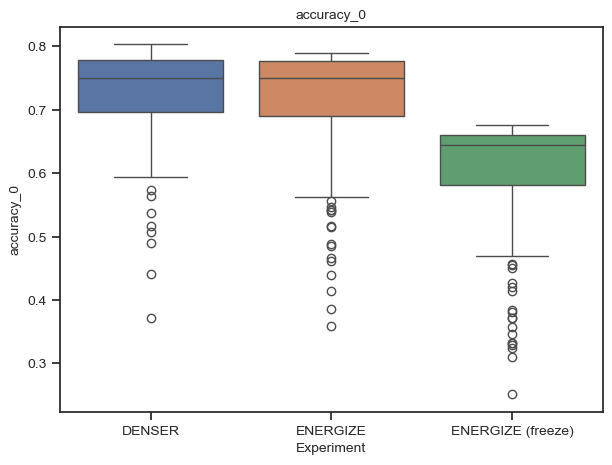

Key: accuracy_1
..Kruskal-Wallis test (alpha=0.05)
....stat=161.336 and p-value=9.256e-36
....reject H0 -> median is not equal across all groups
..Mann-Whitney U test (alpha=0.05, Bonferroni correction)


,DENSER,ENERGIZE,ENERGIZE (freeze)
DENSER,1.000000e+00,1.637257e-02,1.566635e-32
ENERGIZE,1.637257e-02,1.000000e+00,4.803479e-21
ENERGIZE (freeze),1.566635e-32,4.803479e-21,1.000000e+00


<Figure size 7500x3000 with 0 Axes>

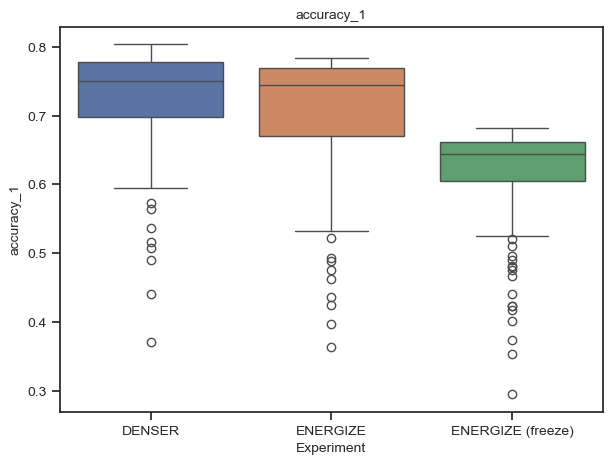

Key: power_train
..Kruskal-Wallis test (alpha=0.05)
....stat=187.561 and p-value=1.869e-41
....reject H0 -> median is not equal across all groups
..Mann-Whitney U test (alpha=0.05, Bonferroni correction)


,DENSER,ENERGIZE,ENERGIZE (freeze)
DENSER,1.000000e+00,2.469535e-06,2.874422e-39
ENERGIZE,2.469535e-06,1.000000e+00,7.228737e-24
ENERGIZE (freeze),2.874422e-39,7.228737e-24,1.000000e+00


<Figure size 7500x3000 with 0 Axes>

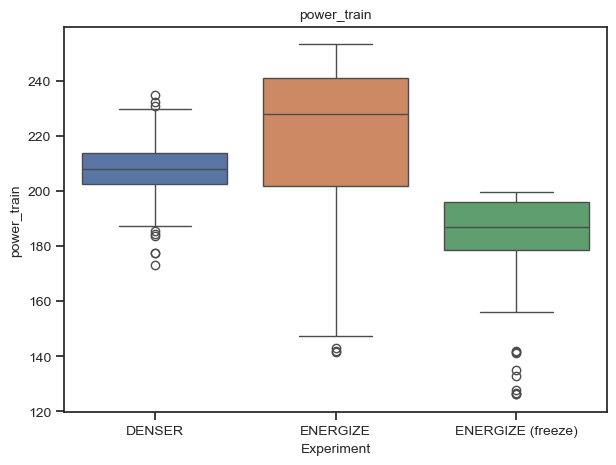

Key: power_test_0_mean
..Kruskal-Wallis test (alpha=0.05)
....stat=230.998 and p-value=6.908e-51
....reject H0 -> median is not equal across all groups
..Mann-Whitney U test (alpha=0.05, Bonferroni correction)


,DENSER,ENERGIZE,ENERGIZE (freeze)
DENSER,1.000000e+00,8.016621e-01,6.518801e-50
ENERGIZE,8.016621e-01,1.000000e+00,1.775052e-29
ENERGIZE (freeze),6.518801e-50,1.775052e-29,1.000000e+00


<Figure size 7500x3000 with 0 Axes>

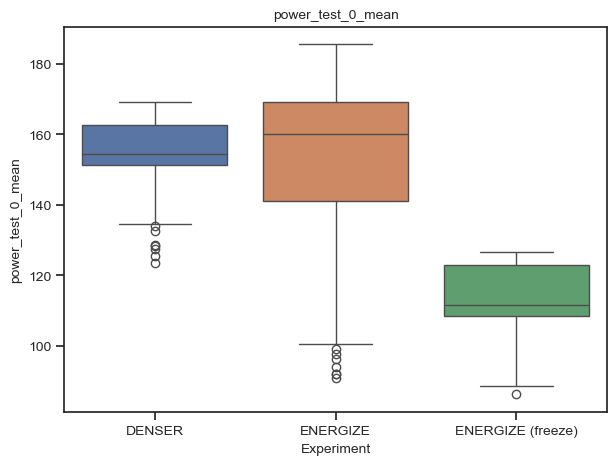

Key: power_test_1_mean
..Kruskal-Wallis test (alpha=0.05)
....stat=226.886 and p-value=5.400e-50
....reject H0 -> median is not equal across all groups
..Mann-Whitney U test (alpha=0.05, Bonferroni correction)


,DENSER,ENERGIZE,ENERGIZE (freeze)
DENSER,1.000000e+00,1.595435e-01,3.438715e-50
ENERGIZE,1.595435e-01,1.000000e+00,4.060237e-26
ENERGIZE (freeze),3.438715e-50,4.060237e-26,1.000000e+00


<Figure size 7500x3000 with 0 Axes>

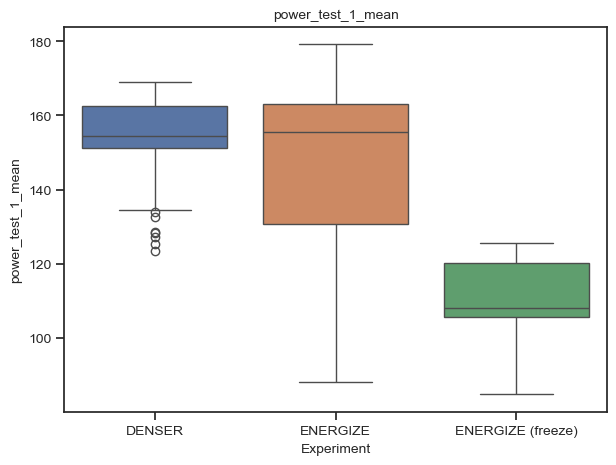

Key: early_stop
..Kruskal-Wallis test (alpha=0.05)
....stat=176.316 and p-value=5.169e-39
....reject H0 -> median is not equal across all groups
..Mann-Whitney U test (alpha=0.05, Bonferroni correction)


,DENSER,ENERGIZE,ENERGIZE (freeze)
DENSER,1.000000e+00,6.030721e-21,3.691552e-05
ENERGIZE,6.030721e-21,1.000000e+00,6.658650e-36
ENERGIZE (freeze),3.691552e-05,6.658650e-36,1.000000e+00


<Figure size 7500x3000 with 0 Axes>

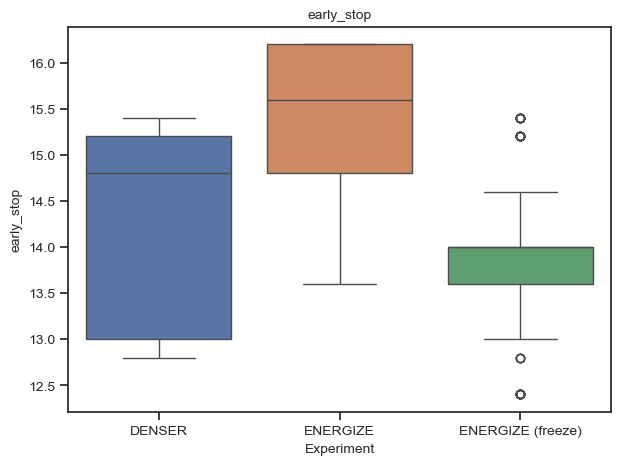

In [19]:
for i, k in enumerate(KEYS):
    print(f"Key: {k}")
    plt.figure(dpi=300)
    data = {
        experiment: experiments_data[experiment]['data'][KEYS_ENERGIZE_TO_DENSER[k] if experiment == 'DENSER' and k in KEYS_ENERGIZE_TO_DENSER else k] for experiment in EXPERIMENTS
    }
    fig, ax = plt.subplots(figsize=(7, 5))
    sn.boxplot(data, ax=ax)
    ax.set_title(k, fontsize=10)
    ax.set_xlabel('Experiment', fontsize=10)
    ax.set_ylabel(k, fontsize=10)
    ax.tick_params(axis='both', which='major', labelsize=10)

    kruskal_test = stats.kruskal(*data.values())
    print(f"..Kruskal-Wallis test (alpha={alpha})")
    print(f"....stat={kruskal_test.statistic:.3f} and p-value={kruskal_test.pvalue:.3e}")
    if kruskal_test.pvalue >= alpha:
        print("....accept H0 -> median is equal across all groups")
    else:
        print("....reject H0 -> median is not equal across all groups")
        print(f"..Mann-Whitney U test (alpha={alpha}, Bonferroni correction)")
        data_df = pd.DataFrame({
            "group": [exp for exp in EXPERIMENTS for _ in range(len(data[exp]))],
            "value": [v for exp in EXPERIMENTS for v in data[exp]]
        })
        posthoc_df = sp.posthoc_mannwhitney(data_df, group_col="group", val_col="value", p_adjust="bonferroni", sort=False)
        display(posthoc_df)
    plt.show()

# Tables

In [20]:
table_rows = []

for key in KEYS:
    for experiment in EXPERIMENTS_WITH_SEED:
        _key = key
        if experiment == 'DENSER' and key in KEYS_ENERGIZE_TO_DENSER:
            _key = KEYS_ENERGIZE_TO_DENSER[key]
        d = experiments_data[experiment]['data'][_key]
        row = {
            'Key': key,
            'Experiment': experiment,
            'Mean': f"{d.mean():.3f}",
            'Std': f"{d.std():.3f}",
            'Median': f"{d.median():.3f}",
            'Min': f"{d.min():.3f}",
            'Max': f"{d.max():.3f}"
        }
        table_rows.append(row)

df = pd.DataFrame(table_rows)
filtered_df = df[df['Key'].isin(('accuracy', 'accuracy_0','power_test_mean', 'power_test_0_mean'))]
display(filtered_df)

percentage_diff_rows = []

for key in KEYS:
    baseline_mean = df[(df['Key'] == key) & (df['Experiment'] == 'DENSER')]['Mean'].astype(float).values[0]
    baseline_median = df[(df['Key'] == key) & (df['Experiment'] == 'DENSER')]['Median'].astype(float).values[0]

    for experiment in ['ENERGIZE', 'ENERGIZE (w/ skip)']:
        mean_value = df[(df['Key'] == key) & (df['Experiment'] == experiment)]['Mean'].astype(float).values[0]
        median_value = df[(df['Key'] == key) & (df['Experiment'] == experiment)]['Median'].astype(float).values[0]

        mean_diff = ((mean_value - baseline_mean) / baseline_mean) * 100
        median_diff = ((median_value - baseline_median) / baseline_median) * 100

        row = {
            'Key': key,
            'Experiment': experiment,
            'Mean % Diff': f"{mean_diff:.2f}%",
            'Median % Diff': f"{median_diff:.2f}%"
        }
        percentage_diff_rows.append(row)

percentage_diff_df = pd.DataFrame(percentage_diff_rows)
filtered_percentage_diff_df = percentage_diff_df[percentage_diff_df['Key'].isin(['accuracy_0', 'power_test_mean', 'power_test_0_mean'])]
display(filtered_percentage_diff_df)

,Key,Experiment,Mean,Std,Median,Min,Max
6,accuracy_0,DENSER,0.726,0.075,0.750,0.371,0.803
7,accuracy_0,ENERGIZE,0.709,0.094,0.751,0.359,0.789
8,accuracy_0,ENERGIZE (freeze),0.599,0.096,0.644,0.251,0.677
15,power_test_0_mean,DENSER,154.594,9.163,154.500,123.509,169.089
16,power_test_0_mean,ENERGIZE,151.030,24.499,160.092,90.913,185.527
17,power_test_0_mean,ENERGIZE (freeze),113.654,8.850,111.467,86.151,126.645


IndexError: index 0 is out of bounds for axis 0 with size 0

In [21]:
import pandas as pd

# Initialize an empty list to store the rows of the table
table_rows = []

for key in KEYS:
    for experiment in EXPERIMENTS_WITH_SEED:
        _key = key
        if experiment == 'DENSER' and key in KEYS_ENERGIZE_TO_DENSER:
            _key = KEYS_ENERGIZE_TO_DENSER[key]
        d = experiments_data[experiment]['data']
        best_idx = d['fitness'].idxmax()
        d = d.loc[best_idx]
        row = {
            'Key': _key,
            'Experiment': experiment,
            'Value': d[_key],
        }
        table_rows.append(row)

df = pd.DataFrame(table_rows)
pd.set_option('display.float_format', lambda x: f"{x:.3f}")
display(df[df['Key'].isin(['accuracy_0', 'power_test_mean', 'power_test_0_mean', 'accuracy'])])
percentage_diff_rows = []

for key in KEYS:
    _key = key
    if key in KEYS_ENERGIZE_TO_DENSER:
        _key = KEYS_ENERGIZE_TO_DENSER[key]
    baseline_df = df[(df['Key'] == _key) & (df['Experiment'] == 'DENSER')]
    if not baseline_df.empty:
        baseline_value = baseline_df['Value'].values[0]

        for experiment in ['ENERGIZE', 'ENERGIZE (w/ skip)']:
            experiment_df = df[(df['Key'] == key) & (df['Experiment'] == experiment)]
            if not experiment_df.empty:
                value = experiment_df['Value'].values[0]
                percentage_diff = ((value - baseline_value) / baseline_value) * 100

                row = {
                    'Key': key,
                    'Experiment': experiment,
                    'Percentage Diff': f"{percentage_diff:.2f}%"
                }
                percentage_diff_rows.append(row)

percentage_diff_df = pd.DataFrame(percentage_diff_rows)
display(percentage_diff_df[percentage_diff_df['Key'].isin(['accuracy_0', 'power_test_mean', 'power_test_0_mean', 'accuracy'])])


,Key,Experiment,Value
6,accuracy,DENSER,0.803
7,accuracy_0,ENERGIZE,0.787
8,accuracy_0,ENERGIZE (freeze),0.668
9,accuracy,DENSER,0.803
15,power_test_mean,DENSER,161.245
16,power_test_0_mean,ENERGIZE,158.075
17,power_test_0_mean,ENERGIZE (freeze),108.030
18,power_test_mean,DENSER,161.245


,Key,Experiment,Percentage Diff
2,accuracy_0,ENERGIZE,-2.08%
5,power_test_0_mean,ENERGIZE,-1.97%


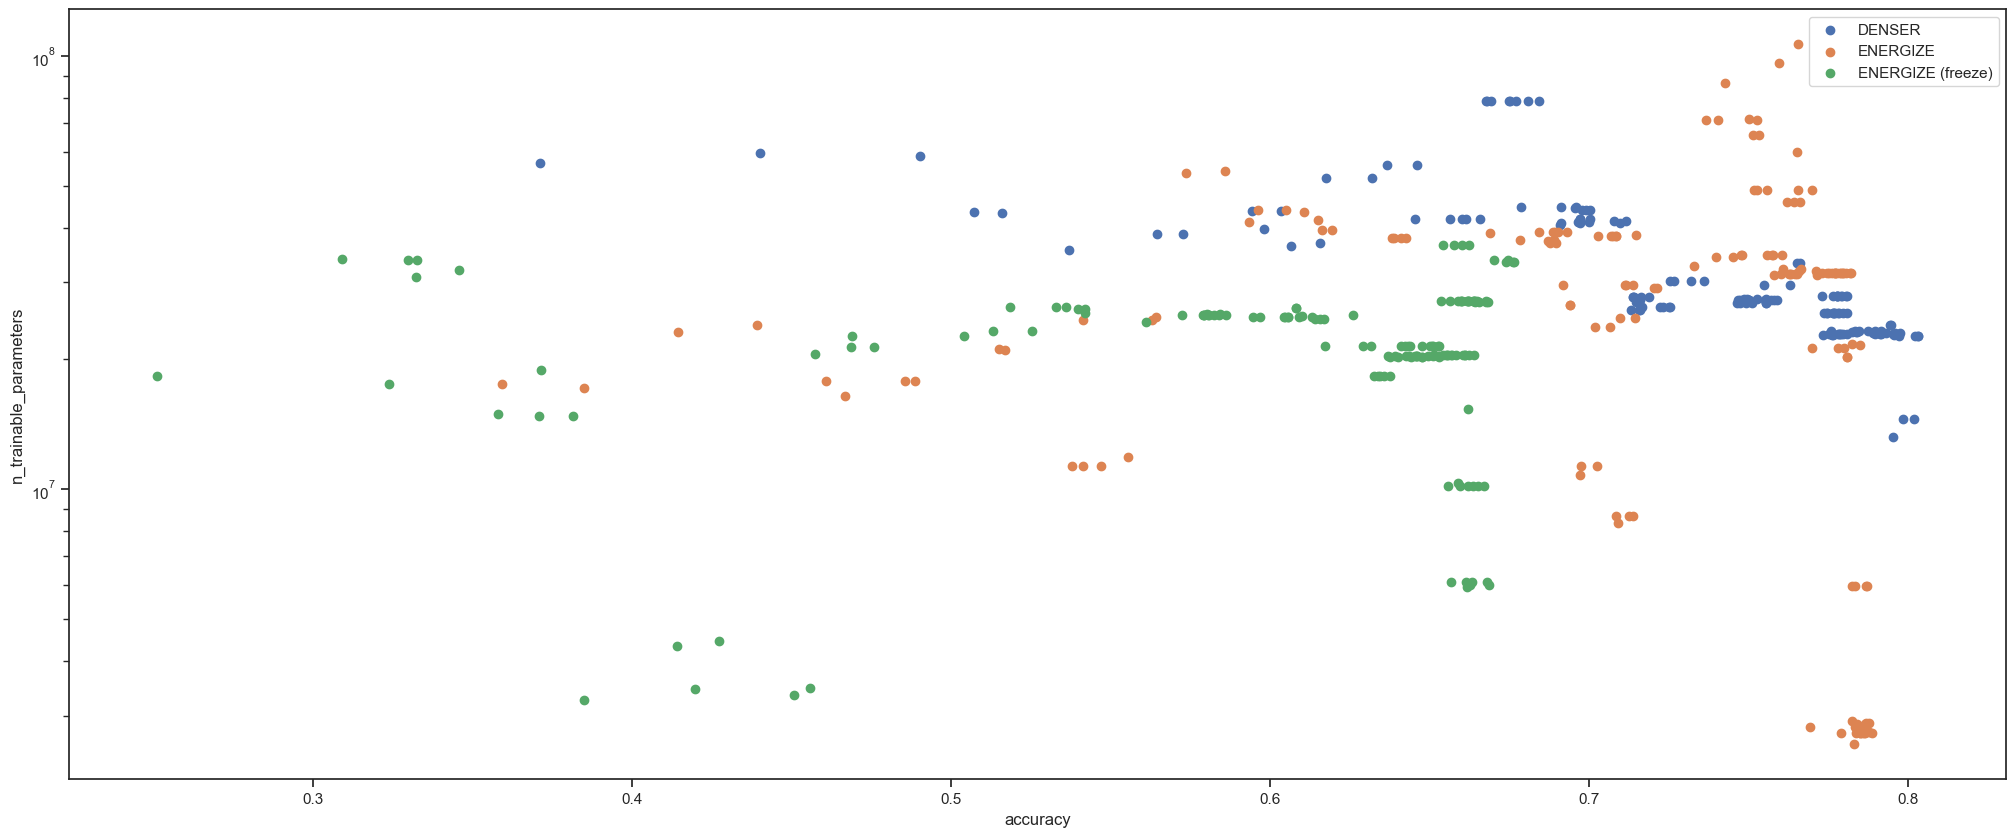

In [22]:
experiments_data
for exp in EXPERIMENTS_WITH_SEED:
    k = 'accuracy' if exp == 'DENSER' else 'accuracy_0'
    plt.scatter(experiments_data[exp]['data'][k], experiments_data[exp]['data']['n_trainable_parameters'], label=exp)
    plt.legend()
    plt.xlabel('accuracy')
    plt.ylabel('n_trainable_parameters')
    plt.yscale('log')